# Term Deposit Subscription
#### Cyrus Majidy

The objective of this project is to help the marketing team identify potential customers who are relatively more likely to subscribe to the term deposit and this increase the hit ratio. The data is from a Portuguese bank on the details of customers related to selling a term deposit. 

In [1]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from os import system
from scipy import stats
from sklearn import metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, accuracy_score 

In [2]:
# Read in the dataframe
df = pd.read_csv('bank-full.csv')

In [3]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [4]:
df.tail(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
45201,53,management,married,tertiary,no,583,no,no,cellular,17,nov,226,1,184,4,success,yes
45202,34,admin.,single,secondary,no,557,no,no,cellular,17,nov,224,1,-1,0,unknown,yes
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,unknown,yes
45204,73,retired,married,secondary,no,2850,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,unknown,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


## Univariate Analysis

In [5]:
df.shape

(45211, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### Most columns of object datatype will need to be one-hot encoded later. For columns like housing, loan, and Target, simply replacing 'yes' and 'no' with '1' and '0' may do.

In [7]:
# Most descriptive statistics can be found using:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
# Median:
df.median()

age          39.0
balance     448.0
day          16.0
duration    180.0
campaign      2.0
pdays        -1.0
previous      0.0
dtype: float64

In [9]:
# Range:
def range(frame):
    for i in ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Target']:
        if frame[i].dtypes == 'int64':
            print(i, ': ', frame[i].max() - frame[i].min())
            
range(df)

age :  77
balance :  110146
day :  30
duration :  4918
campaign :  62
pdays :  872
previous :  275


In [10]:
# Standard Deviation:
df.std()

age           10.618762
balance     3044.765829
day            8.322476
duration     257.527812
campaign       3.098021
pdays        100.128746
previous       2.303441
dtype: float64

In [11]:
# Skewness:
df.skew()

age          0.684818
balance      8.360308
day          0.093079
duration     3.144318
campaign     4.898650
pdays        2.615715
previous    41.846454
dtype: float64

In [12]:
# Duplicated data?
sum(df.duplicated())

0

In [13]:
# Null values?
df.isnull().values.any() 

False

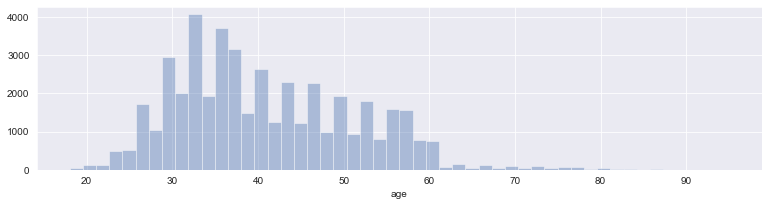

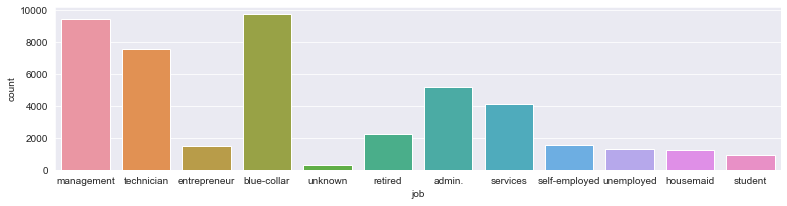

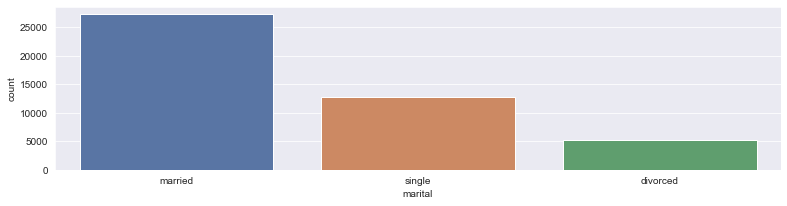

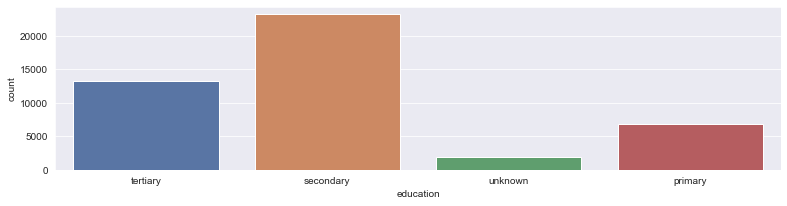

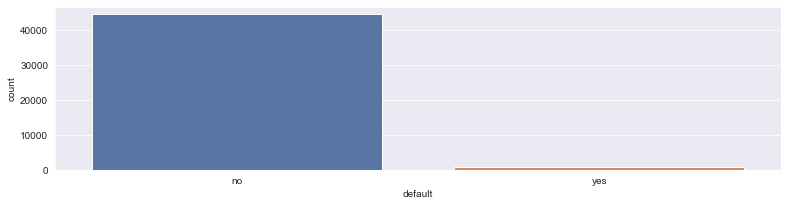

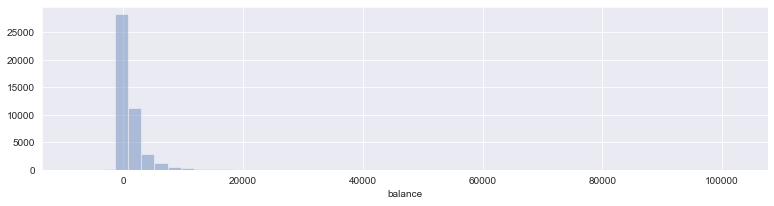

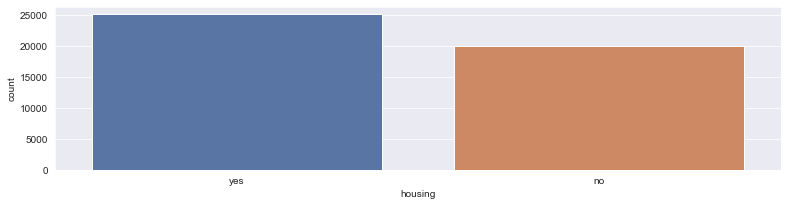

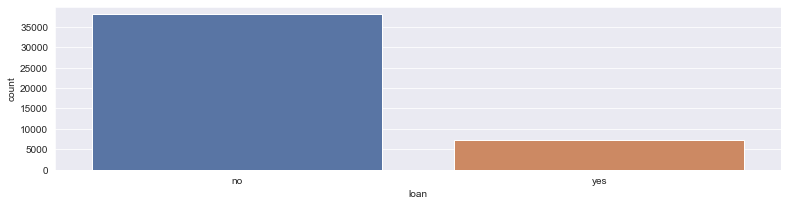

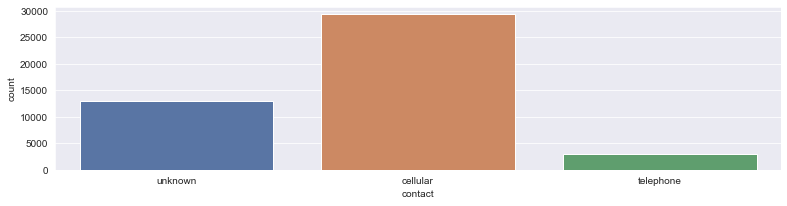

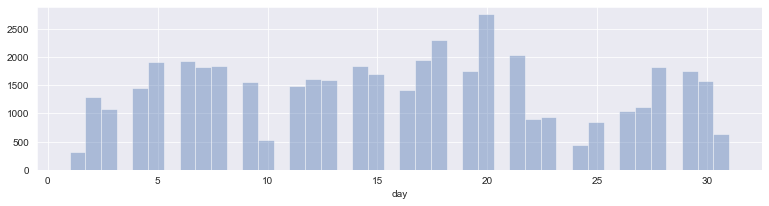

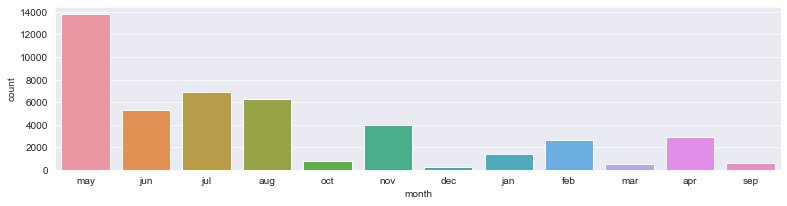

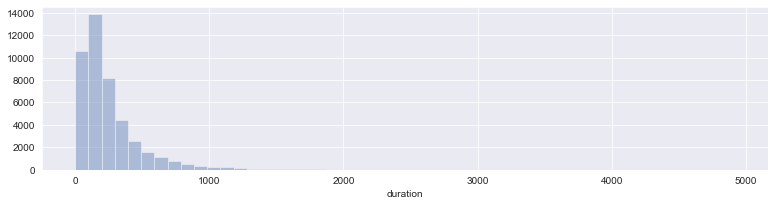

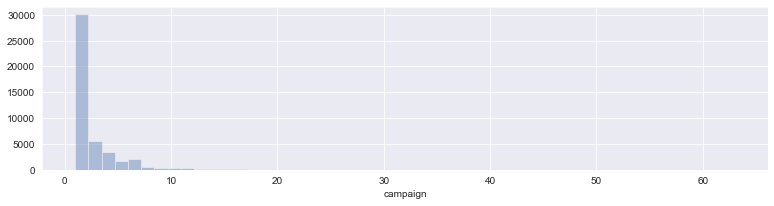

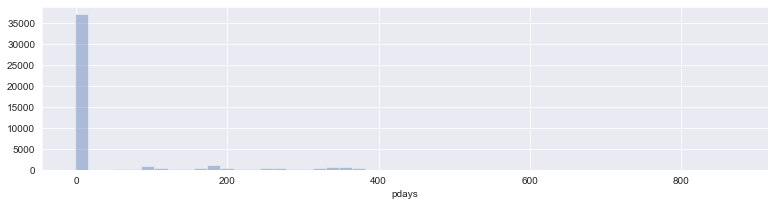

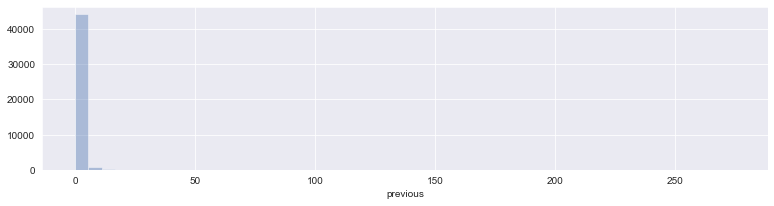

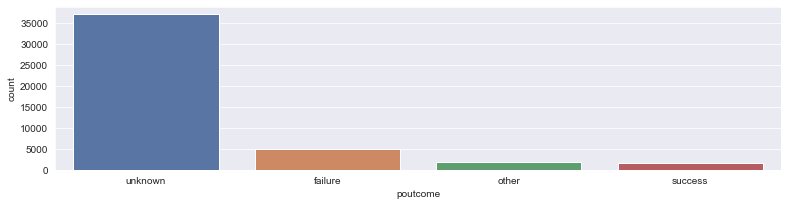

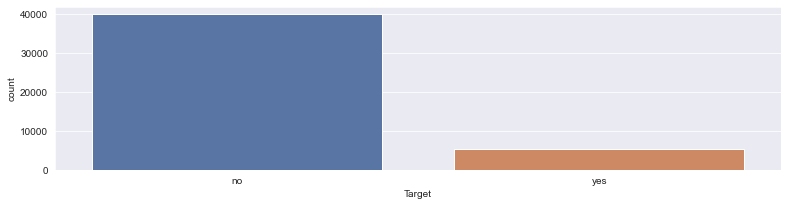

In [14]:
# Function to plot distplots and countplots based on datatype:
sns.set({'figure.figsize': (13,3)})
def univariate(frame):
    for i in ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Target']:
        if frame[i].dtypes == 'int64':
            sns.distplot(df[i], kde=False)
            plt.show()
        else:
            sns.countplot(df[i])
            plt.show()
            
univariate(df)

#### In some categories, unknown values constitute for a high percentage of those values. I want to treat them, but I feel that could be problematic. So, it seems that unknown values no not constitute as missing values. Therefore, I will not be treating them.

#### Identifying outliers:

In [15]:
# IQR:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
IQR

age           15.0
balance     1356.0
day           13.0
duration     216.0
campaign       2.0
pdays          0.0
previous       0.0
dtype: float64

In [16]:
# Using IQR:
np.set_printoptions(threshold = np.inf) # To prevent from the array truncating in the output.
outliers = np.where((df < (Q1 - 1.5 * IQR)) | (df > (Q1 + 1.5 * IQR)))

for i in outliers:
    print(i)

[    0     0     8    12    13    14    17    18    21    30    32    33
    34    35    37    38    40    42    43    44    44    46    53    59
    61    62    65    66    66    67    69    70    70    83    83    83
    85    86    86    87    89    92    92    93    94    97   103   108
   108   109   112   114   116   118   119   120   120   129   129   130
   138   139   142   144   146   149   151   152   157   163   163   168
   170   174   178   179   181   182   185   186   187   189   190   199
   200   202   203   204   205   212   224   226   231   232   232   241
   244   249   249   256   257   260   267   269   270   271   272   273
   275   280   283   291   295   299   302   310   316   323   328   330
   333   333   334   345   347   351   354   364   372   382   383   385
   386   387   388   388   389   390   390   391   394   406   408   411
   412   416   419   420   428   430   431   438   446   446   453   457
   460   465   467   471   474   485   486   487   

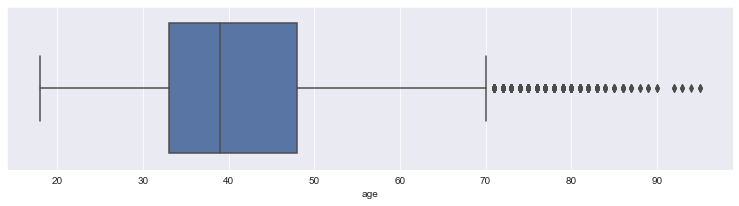

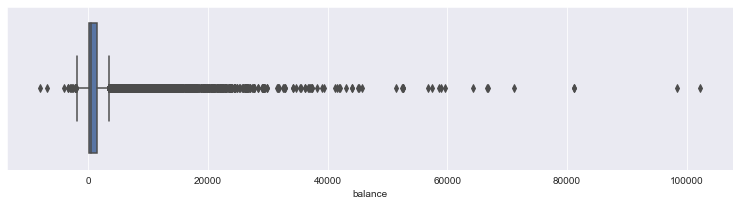

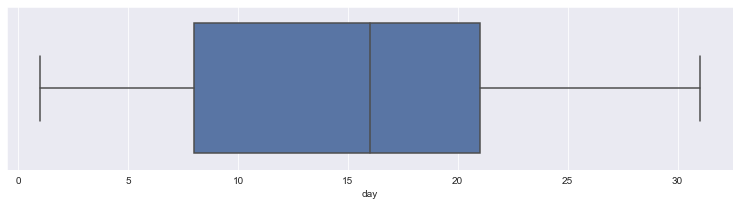

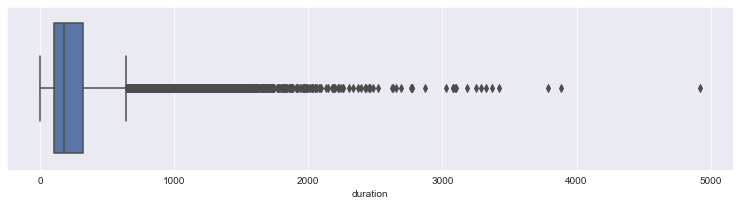

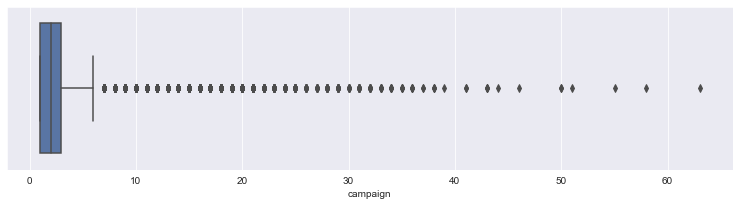

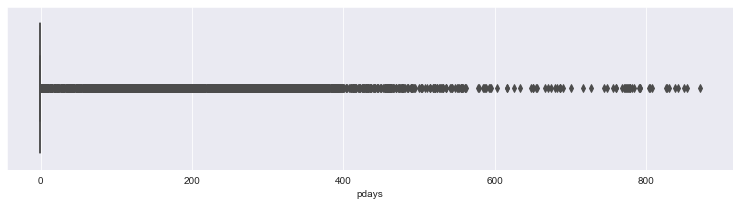

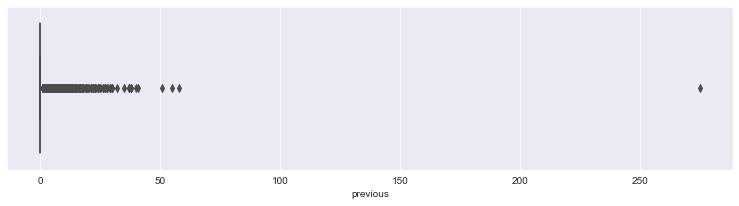

In [17]:
# Using Boxplots:
sns.set({'figure.figsize': (13,3)})
def box_plot(frame):
    for i in ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Target']:
        if frame[i].dtypes == 'int64':
            sns.boxplot(df[i])
            plt.show()
            
box_plot(df)

#### That's astonishing. I'm suspecting that measurements in columns 'previous', 'duration', and 'campaign' may be outliers. I'm tempted to drop values in the other columns. However, dropping in those columns, there's no way to verify if those measurements were taken in eror or not. Especially for the column 'balance.' What if it's just one person who has a significantly greater outcome than everyone else? I will simply need to experiment and see what benefits my model to score higher on the metrics tests. 

#### It seems like very many values are being identified as outliers. In all reality it could just be an insignificant number of outlers, very, very far away from the IQR. It would be best just to make sure.

In [18]:
# How many outliers?
# Using the above tuple "outliers" from np.where(), 
# I should be able to determine the percent of outliers.
# Both values in the tuple are np arrays, 
# One consisting of the values that matched the condition, and one of the indices of those values(rows)

# This should give me the total number of outliers in the data
outliers_1 = list(outliers[0])

num_outliers = 0
for i in outliers_1:
    num_outliers = num_outliers +1
    
print("Total Outliers: ", num_outliers)

# Percent outliers?
print("Shape of data: ", df.shape)
total_data = (45211 * 17)

print("Total Data: ", total_data)

percent_outliers = (num_outliers/total_data) * 100
print("Percent Outliers: ", percent_outliers)


Total Outliers:  48501
Shape of data:  (45211, 17)
Total Data:  768587
Percent Outliers:  6.310411183119152


In [19]:
# Roughly 6.3 of data is being identified as outliers

#### From the IQR, the box plots, and the percentage calculation, it seems like there is a high percentage of the data being identified as outliers. Dropping or replacing all of this may be problematic. There are a few points that can be clearly seen outside of the rest of the data in the boxplots. However, any measure I have attempted to remove those has failed. 

In [15]:
# Time to remove the outliers
# First, need to create some new dataframes, and drop categorical columns.
df_processed = df.copy()

#Drop here
#df.drop('col',axis=1,inplace=True)
df_processed.drop('job',axis=1,inplace=True)
df_processed.drop('marital',axis=1,inplace=True)
df_processed.drop('education',axis=1,inplace=True)
df_processed.drop('default',axis=1,inplace=True)
df_processed.drop('housing',axis=1,inplace=True)
df_processed.drop('loan',axis=1,inplace=True)
df_processed.drop('contact',axis=1,inplace=True)
df_processed.drop('month',axis=1,inplace=True)
df_processed.drop('poutcome',axis=1,inplace=True)
df_processed.drop('Target',axis=1,inplace=True)
   
df_processed.head()

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0


In [21]:
df_zscore = df_processed.copy()

df_zscore = np.abs(stats.zscore(df_zscore)) # Give me the zcore of every value in the df in array

threshold = 20 # 3 by default
for i, j in zip(np.where(df_zscore > threshold)[0], np.where(df_zscore > threshold)[1]):
    df_processed.iloc[i,j] = df_processed.iloc[:,j].median()

#### Replacing outliers with mean/median caused the recall to suffer severely in most models, by one tenth, only improving it slightly by one one hundredth in the Decision Tree model, only while replacing outliers with the median. By modifying the threshold, I was able to get a slight gain in Recall by one-tenth in the Random Forest model. 

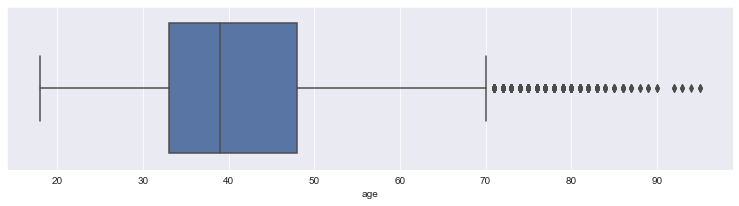

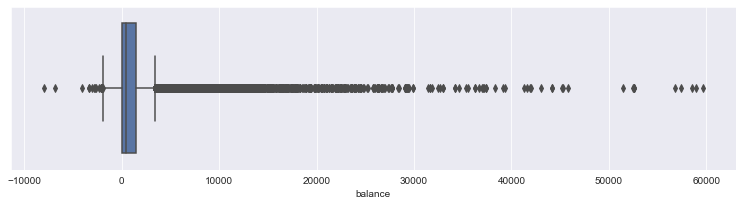

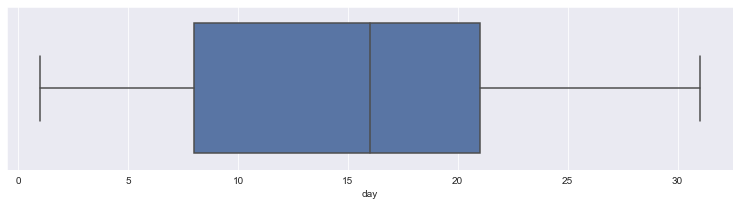

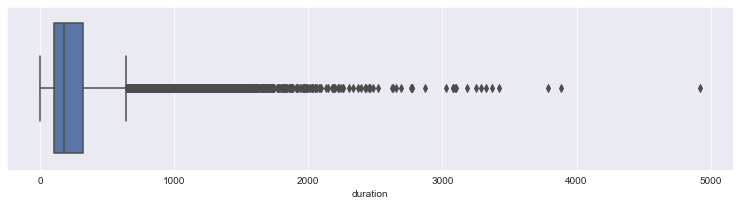

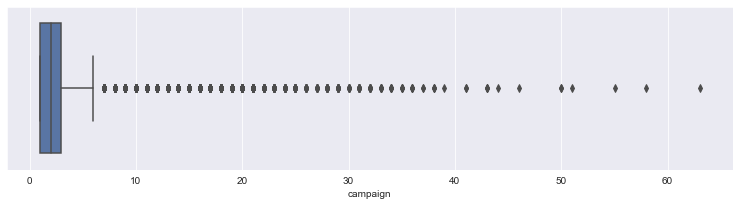

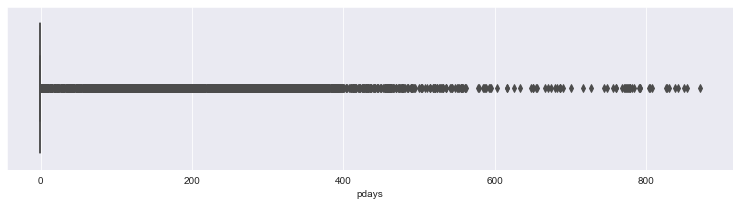

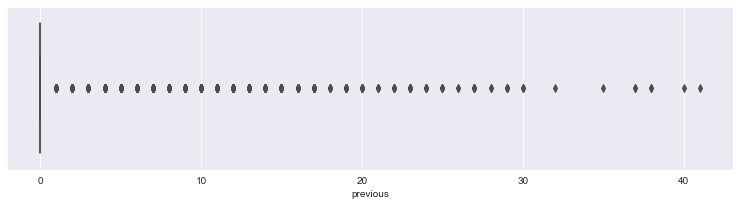

In [22]:
# Show the boxplots again:
sns.set({'figure.figsize': (13,3)})
def box_plot(frame):
    for i in ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']:
        sns.boxplot(frame[i])
        plt.show()
            
box_plot(df_processed)

#### For the sake of the banking industry, removing outliers may not be appropriate, because by all rights, those records shouldn't be wrong. This would be because they are the records of banking customers. Otherwise, if the records were recorded incorrectly, then those are banking customers losing money. So, it may be safe to assume that the records aren't wrong. However, for the sake of this assignment, for the recall score, I have left my outlier treatment in, though it doesn't make much of a difference.

In [16]:
# Might as well do scaling while categorical columns are missing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Store column names for later use
cols = df_processed.columns.tolist()
cols

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [17]:
# Scaling the Data
df_processed = scaler.fit_transform(df_processed)
df_processed

array([[ 1.60696496,  0.25641925, -1.29847633, ..., -0.56935064,
        -0.41145311, -0.25194037],
       [ 0.28852927, -0.43789469, -1.29847633, ..., -0.56935064,
        -0.41145311, -0.25194037],
       [-0.74738448, -0.44676247, -1.29847633, ..., -0.56935064,
        -0.41145311, -0.25194037],
       ...,
       [ 2.92540065,  1.42959305,  0.14341818, ...,  0.72181052,
         1.43618859,  1.05047333],
       [ 1.51279098, -0.22802402,  0.14341818, ...,  0.39902023,
        -0.41145311, -0.25194037],
       [-0.37068857,  0.52836436,  0.14341818, ..., -0.24656035,
         1.4761376 ,  4.52357654]])

In [18]:
# Back to df, using original column names
df_processed = pd.DataFrame(df_processed, columns = cols)
df_processed.head()

,age,balance,day,duration,campaign,pdays,previous
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.25194
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.25194
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.25194
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.25194
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.25194


In [19]:
# Now, time to add the categorical columns back in
df_processed['job'] = df['job']
df_processed['marital'] = df['marital']
df_processed['education'] = df['education']
df_processed['default'] = df['default']
df_processed['housing'] = df['housing']
df_processed['loan'] = df['loan']
df_processed['contact'] = df['contact']
df_processed['month'] = df['month']
df_processed['poutcome'] = df['poutcome']
df_processed['Target'] = df['Target']

df_processed

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome,Target
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.251940,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.251940,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.251940,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.251940,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.251940,unknown,single,unknown,no,no,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.176460,0.143418,2.791329,0.076230,-0.411453,-0.251940,technician,married,tertiary,no,no,no,cellular,nov,unknown,yes
45207,2.831227,0.120447,0.143418,0.768224,-0.246560,-0.411453,-0.251940,retired,divorced,primary,no,no,no,cellular,nov,unknown,yes
45208,2.925401,1.429593,0.143418,3.373797,0.721811,1.436189,1.050473,retired,married,secondary,no,no,no,cellular,nov,success,yes
45209,1.512791,-0.228024,0.143418,0.970146,0.399020,-0.411453,-0.251940,blue-collar,married,secondary,no,no,no,telephone,nov,unknown,no


# Multivariate/Bivariate Analysis

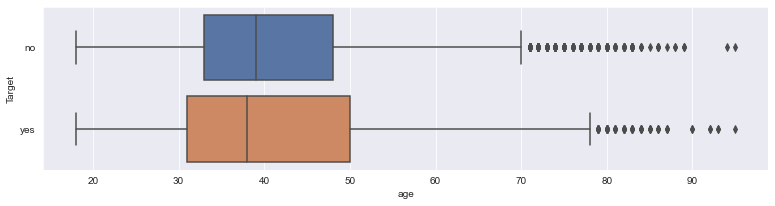

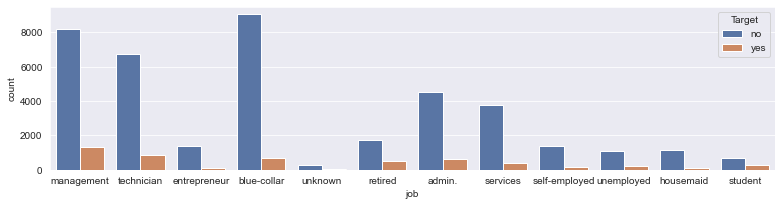

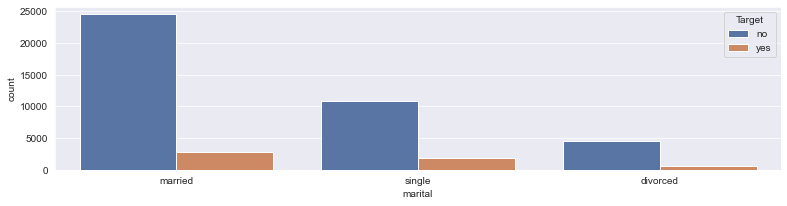

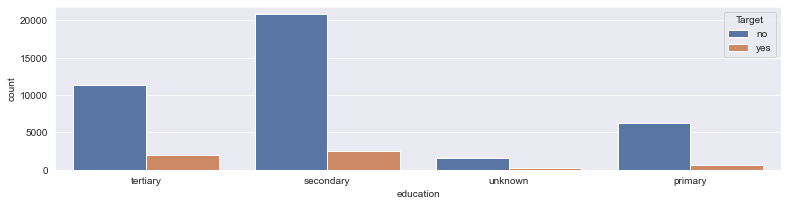

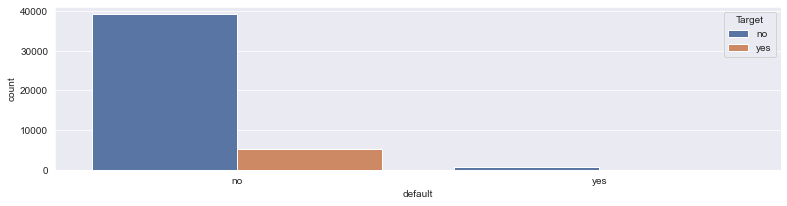

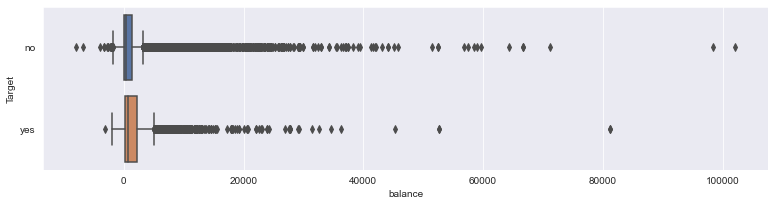

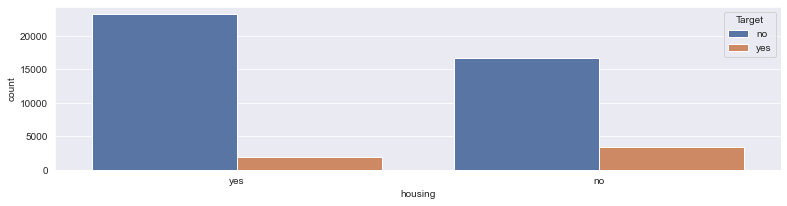

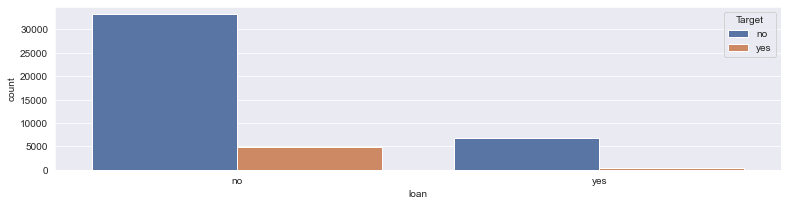

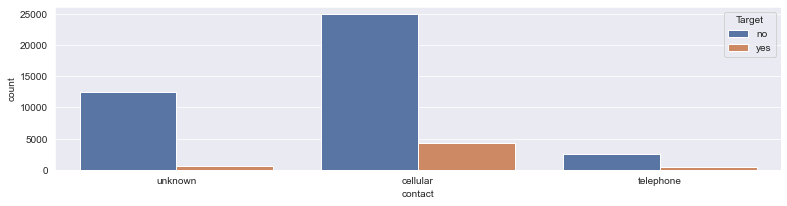

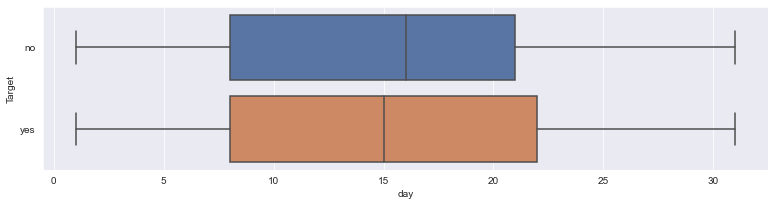

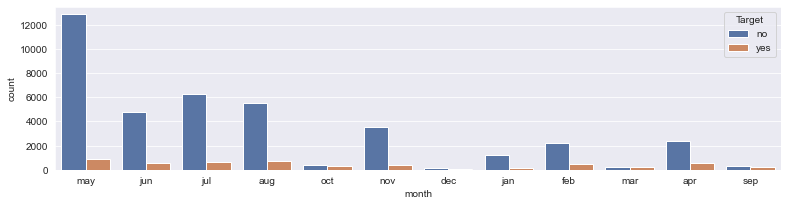

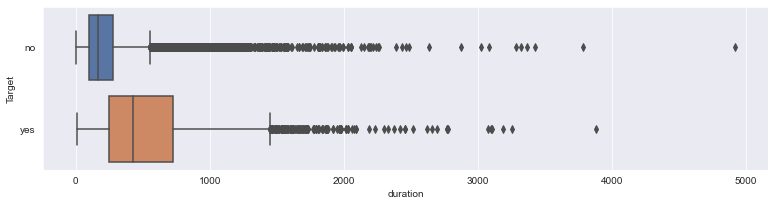

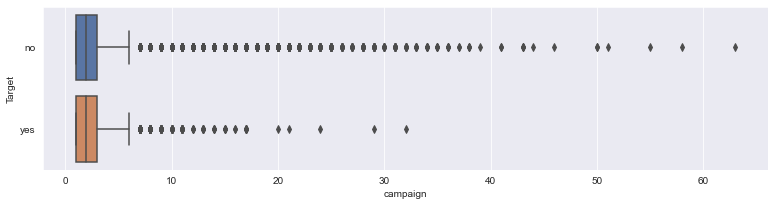

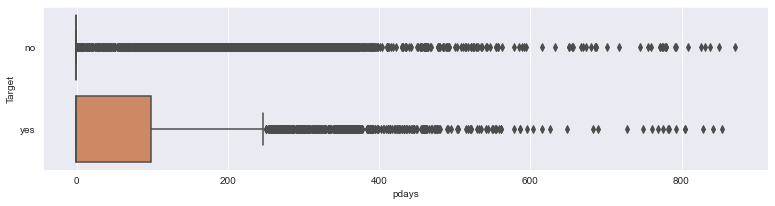

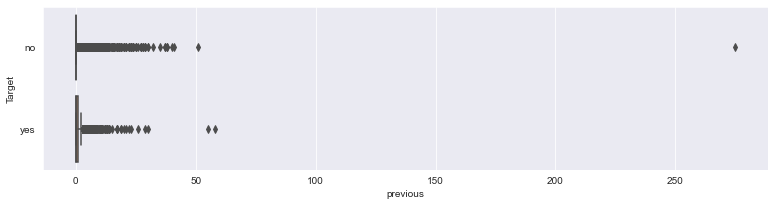

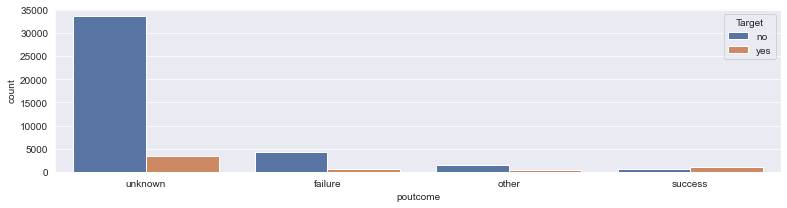

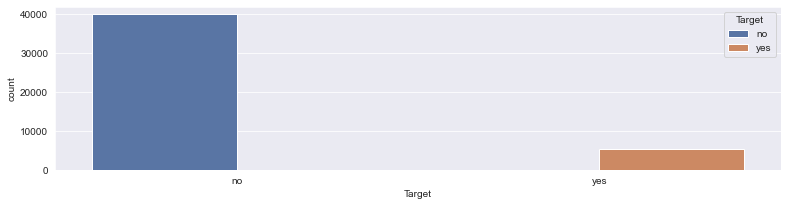

In [20]:
# Bivariate function:
sns.set({'figure.figsize': (13,3)})
def bivariate(frame):
    for i in ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Target']:
        if frame[i].dtypes == 'int64':
            sns.boxplot(df[i], df['Target'])
            plt.show()
        else:
            sns.countplot(df[i], hue=df['Target'])
            plt.show()
            
bivariate(df)

## Creating Dummies

In [21]:
# Most columns of object datatype need to be one-hot encoded.
# For columns default, housing, loan, and Target,
# Simply replacing 'yes' and 'no' with '1' and '0' may do.

In [22]:
replaceStruct = {
                "default": {"no": 0, "yes": 1 },
                "housing": {"no": 0, "yes": 1 },
                 "loan": {"no": 0, "yes": 1 },
                 "Target": {"no": 0, "yes": 1 },
                    }

df_processed=df_processed.replace(replaceStruct)

In [23]:
oneHotCols=["job","marital","education","contact", "month", "poutcome"]

df_processed=pd.get_dummies(df_processed, columns=oneHotCols)

In [24]:
df_processed.head()

,age,balance,day,duration,campaign,pdays,previous,default,housing,loan,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.25194,0,1,0,...,0,0,1,0,0,0,0,0,0,1
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.25194,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.25194,0,1,1,...,0,0,1,0,0,0,0,0,0,1
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.25194,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.25194,0,0,0,...,0,0,1,0,0,0,0,0,0,1


## Heatmap and Pairplots

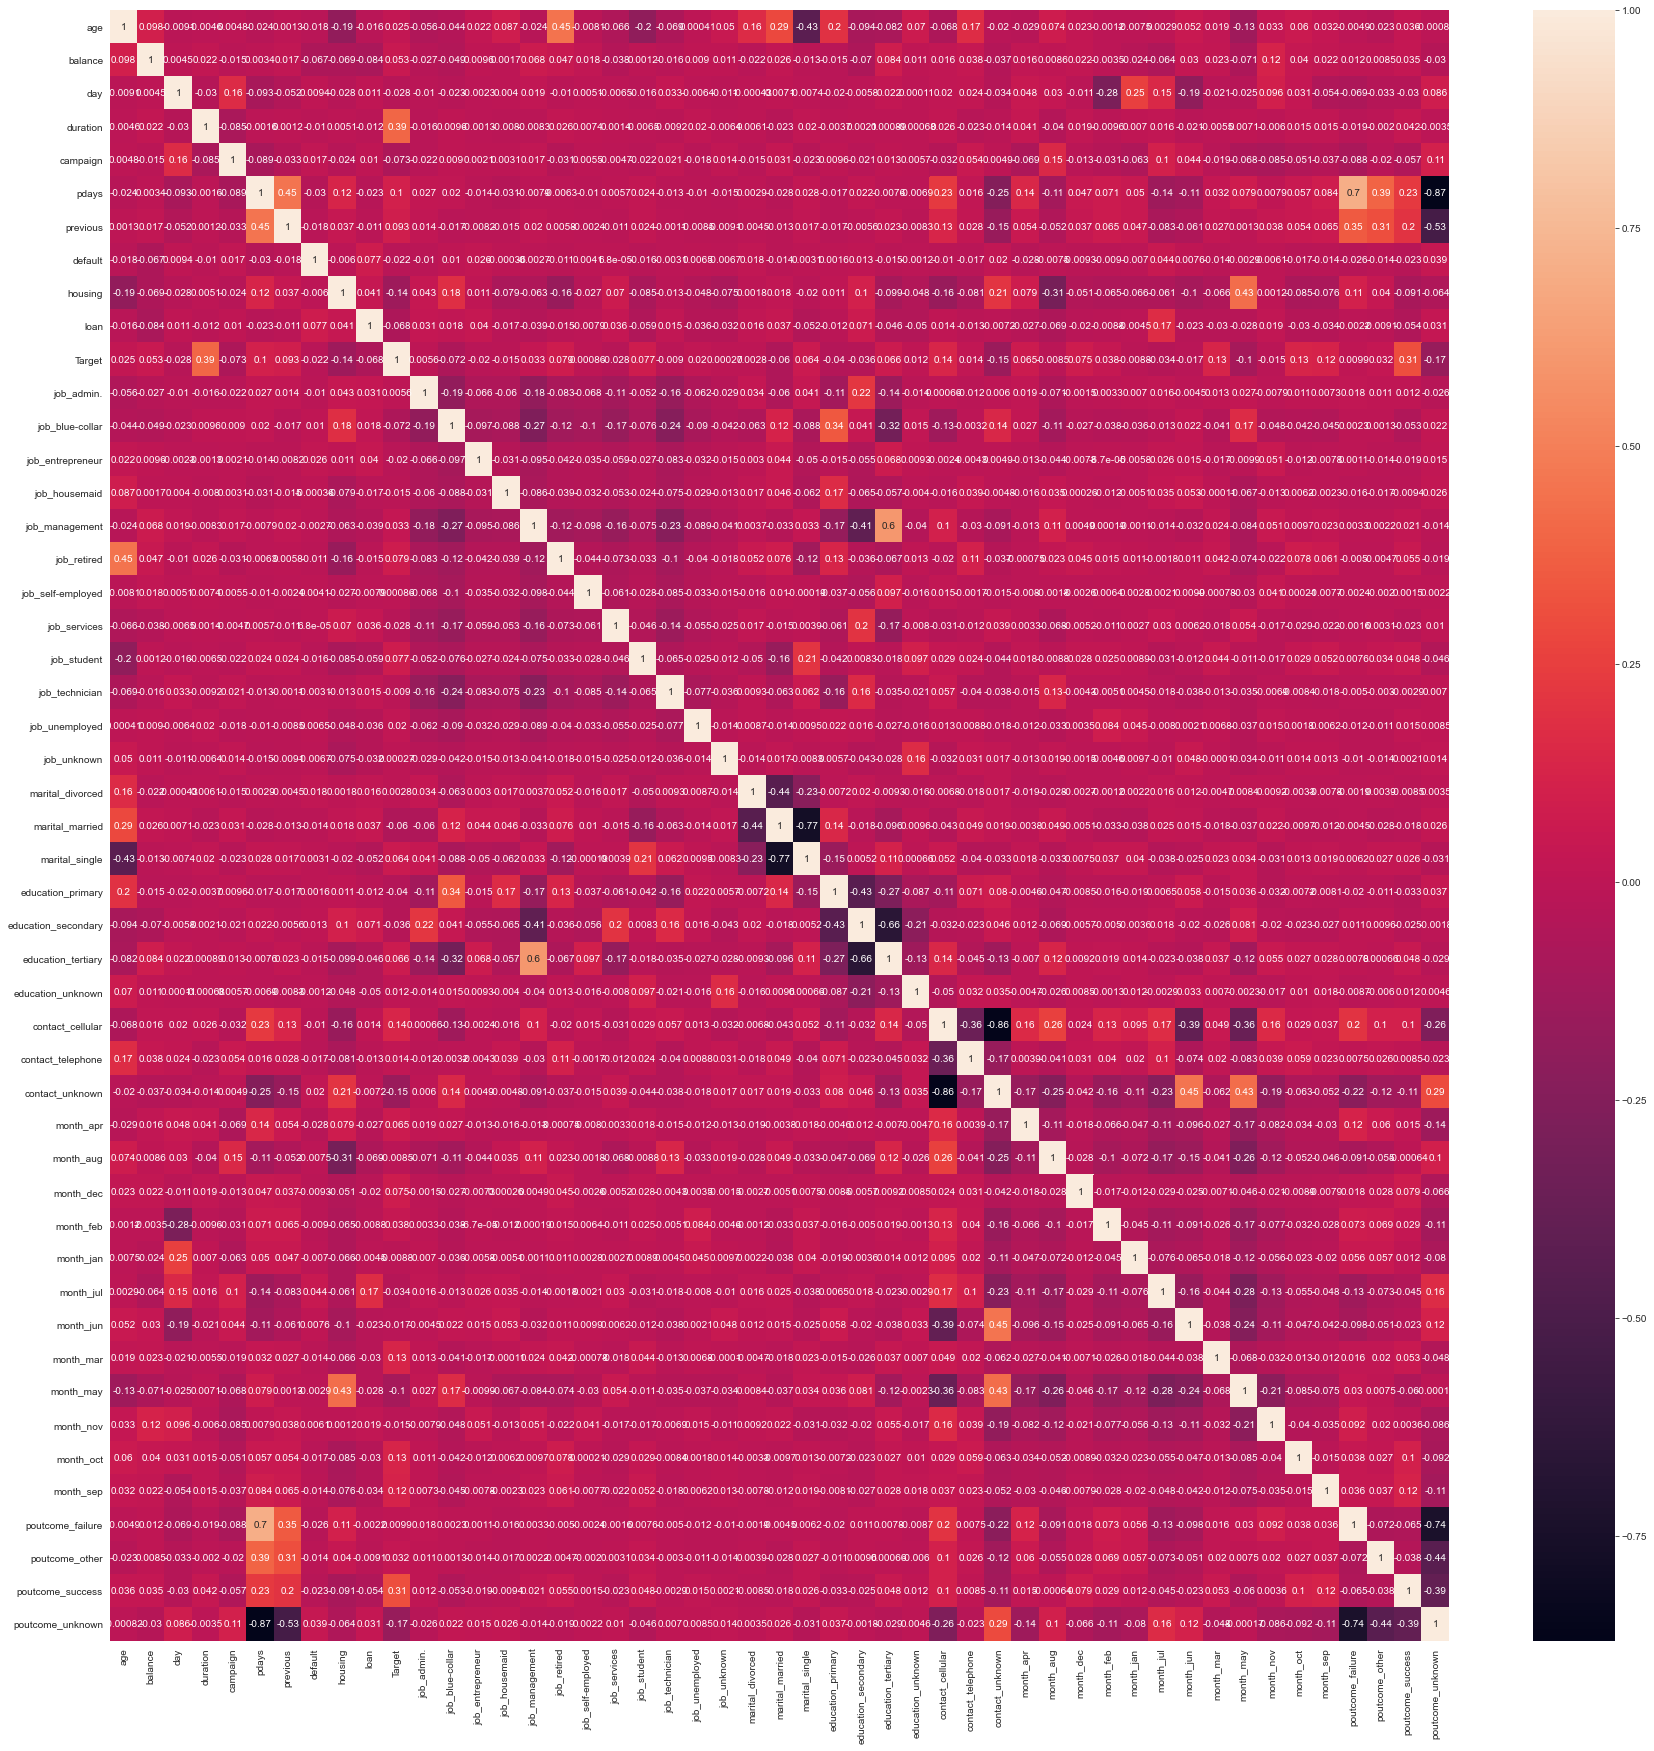

In [25]:
sns.set({'figure.figsize': (30,30)})
sns.heatmap(df_processed.corr(), annot=True);

#### No real coorelation except between other columns such as pdays vs. poutcome, education vs. job, month vs. contact, month vs. housing, and pdays vs. previous. Those aren't the relationships we're looking for though. No real coorelation between any one variable and the Target column except with poutcome_success and duration, and not more than 0.4.

## Creating Dummies

In [27]:
# Done during Multivariate analysis.

## Splitting the Data

#### Note: I used random_state = 7 in all of my models.

In [28]:
x = df_processed.drop('Target', axis=1)
y = df_processed['Target']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7, stratify=y)

In [30]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))
print()
print(f"Train instances by class: {np.bincount(y_train)}")
print(f"Test instances by class: {np.bincount(y_test)}")

(array([0, 1]), array([27945,  3702]))
(array([0, 1]), array([11977,  1587]))

Train instances by class: [27945  3702]
Test instances by class: [11977  1587]


In [31]:
# Creating the DataFrame that will show the metrics of each model side by side
metrics_df = pd.DataFrame(
                    index=['Decision Tree', 'Random Forest', 'Bagging Classifier', 'AdaBoost', 'GradientBoost'])

## Decision Tree

Training accuracy:   0.8998641261414984 

Testing accuracy:   0.901061633736361 

Recall:   0.3320730938878387 

Precision:   0.6514215080346106 

F1 Score:   0.4398998330550918 

ROC AUC Score:   0.6542639828627638 

Confusion Matrix:   



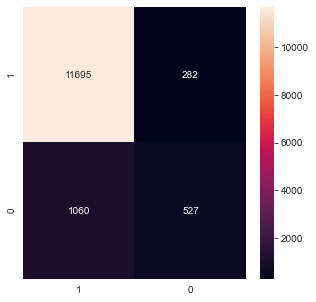

In [32]:
dTree = DecisionTreeClassifier(criterion = 'entropy', max_depth=4, random_state=7)
dTree.fit(x_train, y_train)

y_predict = dTree.predict(x_test)

print("Training accuracy:  ", dTree.score(x_train, y_train), "\n")
print("Testing accuracy:  ", dTree.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 

# Reverse array to display confusion matrix in heatmap right-side-up
cm_array = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
cm = np.flip(cm_array)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [33]:
# Creating the lists to be columns of the metrics DataFrame
Training_Accuracy = [dTree.score(x_train, y_train)]
Testing_Accuracy = [dTree.score(x_test, y_test)]
Recall = [recall_score(y_test, y_predict)]
Precision = [precision_score(y_test, y_predict)]
F1_Score = [f1_score(y_test, y_predict)]
ROC_AUC_Score = [roc_auc_score(y_test, y_predict)]

## Random Forest

Training accuracy:   0.9997472114260435 

Testing accuracy:   0.9057062813329402 

Recall:   0.3812224322621298 

Precision:   0.6707317073170732 

F1 Score:   0.48613901165126555 

ROC AUC Score:   0.6782124518328267 

Confusion Matrix:   



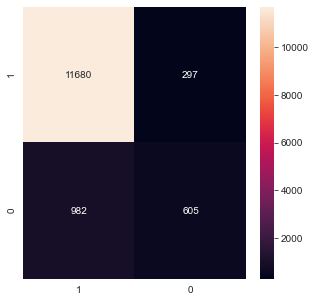

In [34]:
from sklearn.ensemble import RandomForestClassifier
rfcl = RandomForestClassifier(n_estimators = 50, random_state=7) 
#, max_features = 12
rfcl = rfcl.fit(x_train, y_train)

y_predict = rfcl.predict(x_test)

print("Training accuracy:  ", rfcl.score(x_train, y_train), "\n")
print("Testing accuracy:  ", rfcl.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [35]:
#Adding this model's metrics to the lists
Training_Accuracy.append(rfcl.score(x_train, y_train))
Testing_Accuracy.append(rfcl.score(x_test, y_test))
Recall.append(recall_score(y_test, y_predict))
Precision.append(precision_score(y_test, y_predict))
F1_Score.append(f1_score(y_test, y_predict))
ROC_AUC_Score.append(roc_auc_score(y_test, y_predict))

## Bagging

Training accuracy:   0.9015704490157045 

Testing accuracy:   0.9031259215570628 

Recall:   0.3572778827977316 

Precision:   0.6585365853658537 

F1 Score:   0.46323529411764713 

ROC AUC Score:   0.6663654171440441 

Confusion Matrix:   



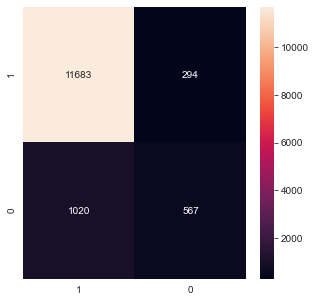

In [36]:
from sklearn.ensemble import BaggingClassifier

bgcl = BaggingClassifier(base_estimator=dTree, n_estimators=50, random_state=7)
bgcl = bgcl.fit(x_train, y_train)

y_predict = bgcl.predict(x_test)

print("Training accuracy:  ", bgcl.score(x_train, y_train), "\n")
print("Testing accuracy:  ", bgcl.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [37]:
#Adding this model's metrics to the lists
Training_Accuracy.append(bgcl.score(x_train, y_train))
Testing_Accuracy.append(bgcl.score(x_test, y_test))
Recall.append(recall_score(y_test, y_predict))
Precision.append(precision_score(y_test, y_predict))
F1_Score.append(f1_score(y_test, y_predict))
ROC_AUC_Score.append(roc_auc_score(y_test, y_predict))

## Boosting

### AdaBoost

Training accuracy:   0.896325086106108 

Testing accuracy:   0.8974491300501327 

Recall:   0.32325141776937616 

Precision:   0.6180722891566265 

F1 Score:   0.42449317335539927 

ROC AUC Score:   0.6483920109636728 

Confusion Matrix:   



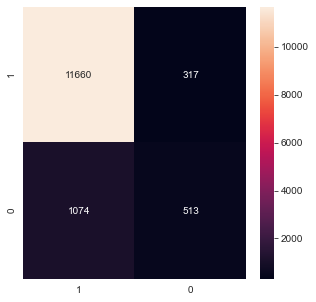

In [38]:
from sklearn.ensemble import AdaBoostClassifier

abcl = AdaBoostClassifier(n_estimators=10, random_state=7)
abcl = abcl.fit(x_train, y_train)

y_predict = abcl.predict(x_test)

print("Training accuracy:  ", abcl.score(x_train, y_train), "\n")
print("Testing accuracy:  ", abcl.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [39]:
#Adding this model's metrics to the lists
Training_Accuracy.append(abcl.score(x_train, y_train))
Testing_Accuracy.append(abcl.score(x_test, y_test))
Recall.append(recall_score(y_test, y_predict))
Precision.append(precision_score(y_test, y_predict))
F1_Score.append(f1_score(y_test, y_predict))
ROC_AUC_Score.append(roc_auc_score(y_test, y_predict))

### GradientBoost

Training accuracy:   0.9066894176383228 

Testing accuracy:   0.9053376585078148 

Recall:   0.3667296786389414 

Precision:   0.6759581881533101 

F1 Score:   0.4754901960784314 

ROC AUC Score:   0.6717175152817317 

Confusion Matrix:   



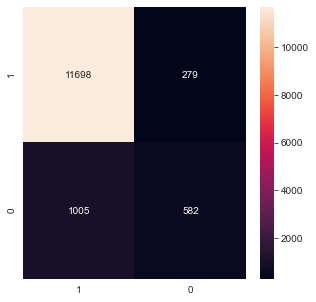

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gbcl = GradientBoostingClassifier(n_estimators = 50, random_state=7)
gbcl = gbcl.fit(x_train, y_train)

y_predict = gbcl.predict(x_test)

print("Training accuracy:  ", gbcl.score(x_train, y_train), "\n")
print("Testing accuracy:  ", gbcl.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [41]:
Training_Accuracy.append(gbcl.score(x_train, y_train))
Testing_Accuracy.append(gbcl.score(x_test, y_test))
Recall.append(recall_score(y_test, y_predict))
Precision.append(precision_score(y_test, y_predict))
F1_Score.append(f1_score(y_test, y_predict))
ROC_AUC_Score.append(roc_auc_score(y_test, y_predict))

# We can now see each completed list.
print(Training_Accuracy)
print(Testing_Accuracy)
print(Recall)
print(Precision)
print(F1_Score)
print(ROC_AUC_Score)

[0.8998641261414984, 0.9997472114260435, 0.9015704490157045, 0.896325086106108, 0.9066894176383228]
[0.901061633736361, 0.9057062813329402, 0.9031259215570628, 0.8974491300501327, 0.9053376585078148]
[0.3320730938878387, 0.3812224322621298, 0.3572778827977316, 0.32325141776937616, 0.3667296786389414]
[0.6514215080346106, 0.6707317073170732, 0.6585365853658537, 0.6180722891566265, 0.6759581881533101]
[0.4398998330550918, 0.48613901165126555, 0.46323529411764713, 0.42449317335539927, 0.4754901960784314]
[0.6542639828627638, 0.6782124518328267, 0.6663654171440441, 0.6483920109636728, 0.6717175152817317]


# DataFrame of Results

In [49]:
# Assembling the dataframe from the lists
metrics_df['Training Accuracy'] = Training_Accuracy
metrics_df['Testing Accuracy'] = Testing_Accuracy
metrics_df['Recall'] = Recall
metrics_df['Precision'] = Precision
metrics_df['F1 Score'] = F1_Score
metrics_df['ROC AUC Score'] = ROC_AUC_Score

print('Metrics')
metrics_df

Metrics


,Training Accuracy,Testing Accuracy,Recall,Precision,F1 Score,ROC AUC Score
Decision Tree,0.899864,0.901062,0.332073,0.651422,0.439900,0.654264
Random Forest,0.999589,0.904600,0.378702,0.661166,0.481571,0.676493
Bagging Classifier,0.901570,0.903273,0.357908,0.659698,0.464052,0.666722
AdaBoost,0.896325,0.897449,0.323251,0.618072,0.424493,0.648392
GradientBoost,0.906753,0.905264,0.365469,0.675991,0.474438,0.671129


In [42]:
# Assembling the dataframe from the lists
metrics_df['Training Accuracy'] = Training_Accuracy
metrics_df['Testing Accuracy'] = Testing_Accuracy
metrics_df['Recall'] = Recall
metrics_df['Precision'] = Precision
metrics_df['F1 Score'] = F1_Score
metrics_df['ROC AUC Score'] = ROC_AUC_Score

print('Metrics')
metrics_df

Metrics


,Training Accuracy,Testing Accuracy,Recall,Precision,F1 Score,ROC AUC Score
Decision Tree,0.899864,0.901062,0.332073,0.651422,0.439900,0.654264
Random Forest,0.999747,0.905706,0.381222,0.670732,0.486139,0.678212
Bagging Classifier,0.901570,0.903126,0.357278,0.658537,0.463235,0.666365
AdaBoost,0.896325,0.897449,0.323251,0.618072,0.424493,0.648392
GradientBoost,0.906689,0.905338,0.366730,0.675958,0.475490,0.671718


# Conclusions

   The precision and recall scores show that not enough true positives were identified. That is, not enough customers were predicted. To my knowledge, precision and recall are the best metrics for evaluating the effectiveness of a model. I would select the Random Forest model, since my scores were highest in that one.
    
Suggestions for the bank:

   Try to maximize contact durration. Perhaps focus more on the success of the marketing campaigns. The outcome of the previous campaign, it's success, seems to hold little bit of influence over gaining term deposit customers. Mode of interaction does not appear to hold sway over anything meaningful. Poutcome and duration should be points of focus. This is because there was some noticeable coorelation between poutcome success and duration, both with the target variable.  